<a href="https://colab.research.google.com/github/Juadrg/Estructuta-de-base-de-datos/blob/main/Laboratorio4/laboratorio_quadtree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math

# nodo del quadtree
class Nodo:
    def __init__(self, x1, y1, x2, y2, puntos, cap=4):
        self.x1 = x1
        self.y1 = y1
        self.x2 = x2
        self.y2 = y2
        self.puntos = puntos
        self.cap = cap

        self.div = False
        self.ne = None
        self.nw = None
        self.se = None
        self.sw = None

        if len(puntos) > cap:
            self.dividir()

    def dividir(self):
        mx = (self.x1 + self.x2) / 2
        my = (self.y1 + self.y2) / 2

        ne, nw, se, sw = [], [], [], []

        for p in self.puntos:
            x, y = p
            if x >= mx and y >= my:
                ne.append(p)
            elif x < mx and y >= my:
                nw.append(p)
            elif x >= mx and y < my:
                se.append(p)
            else:
                sw.append(p)

        self.ne = Nodo(mx, my, self.x2, self.y2, ne, self.cap)
        self.nw = Nodo(self.x1, my, mx, self.y2, nw, self.cap)
        self.se = Nodo(mx, self.y1, self.x2, my, se, self.cap)
        self.sw = Nodo(self.x1, self.y1, mx, my, sw, self.cap)

        self.puntos = []
        self.div = True


# crear árbol
def quad(puntos):
    return Nodo(0, 0, 10000, 10000, puntos)



def dist(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)



def radio(nodo, q, r, res=None):
    if res is None:
        res = []


    if not inter(nodo, q, r):
        return res

    if nodo.div:
        radio(nodo.ne, q, r, res)
        radio(nodo.nw, q, r, res)
        radio(nodo.se, q, r, res)
        radio(nodo.sw, q, r, res)
    else:
        for p in nodo.puntos:
            if dist(p, q) <= r:
                res.append(p)

    return res



def inter(nodo, q, r):
    x, y = q

    x_cerca = max(nodo.x1, min(x, nodo.x2))
    y_cerca = max(nodo.y1, min(y, nodo.y2))

    return dist((x_cerca, y_cerca), q) <= r


# vecino más cercano
def cercano(nodo, q, mejor=None):
    if nodo.div:
        mejor = cercano(nodo.ne, q, mejor)
        mejor = cercano(nodo.nw, q, mejor)
        mejor = cercano(nodo.se, q, mejor)
        mejor = cercano(nodo.sw, q, mejor)
    else:
        for p in nodo.puntos:
            if mejor is None or dist(p, q) < dist(mejor, q):
                mejor = p

    return mejor

test

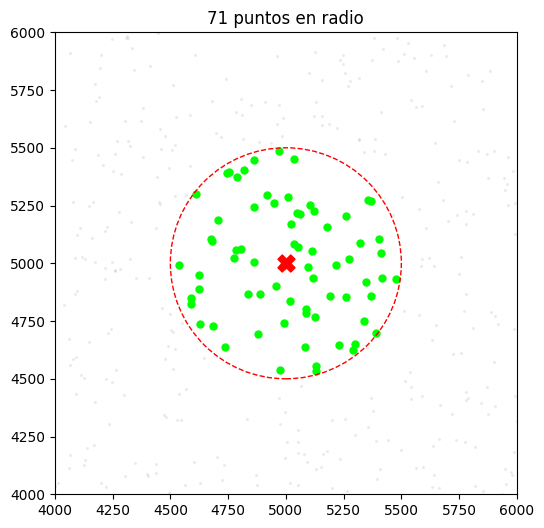

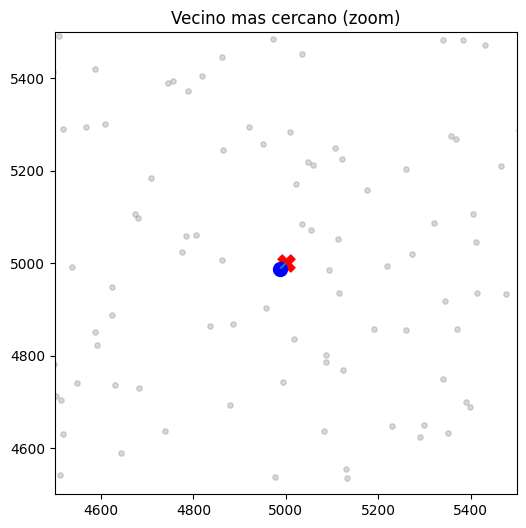

In [ ]:
import random
import matplotlib.pyplot as plt



puntos = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(10000)]
arbol = quad(puntos)

q = (5000, 5000)
r = 500

vecinos = radio(arbol, q, r)
cerca = cercano(arbol, q)

x, y = zip(*puntos)


plt.figure(figsize=(6, 6))

plt.scatter(x, y, s=2, color='gray', alpha=0.1)

if vecinos:
    vx, vy = zip(*vecinos)
    plt.scatter(vx, vy, s=25, color='lime')

plt.scatter(q[0], q[1], color='red', marker='X', s=150)

circulo = plt.Circle(q, r, color='red', fill=False, linestyle='--')
plt.gca().add_patch(circulo)

# zoom
margen = r * 2
plt.xlim(q[0] - margen, q[0] + margen)
plt.ylim(q[1] - margen, q[1] + margen)

plt.title(f"{len(vecinos)} puntos en radio")
plt.gca().set_aspect('equal')
plt.show()


plt.figure(figsize=(6, 6))

zona = radio(arbol, q, r * 2)
zx, zy = zip(*zona)
plt.scatter(zx, zy, s=15, color='gray', alpha=0.3)

plt.scatter(q[0], q[1], color='red', marker='X', s=150)

if cerca:
    plt.scatter(cerca[0], cerca[1], color='blue', s=100)
    plt.plot([q[0], cerca[0]], [q[1], cerca[1]], linestyle='--')

plt.xlim(q[0] - r, q[0] + r)
plt.ylim(q[1] - r, q[1] + r)

plt.title("Vecino mas cercano (zoom)")
plt.gca().set_aspect('equal')
plt.show()

analisis

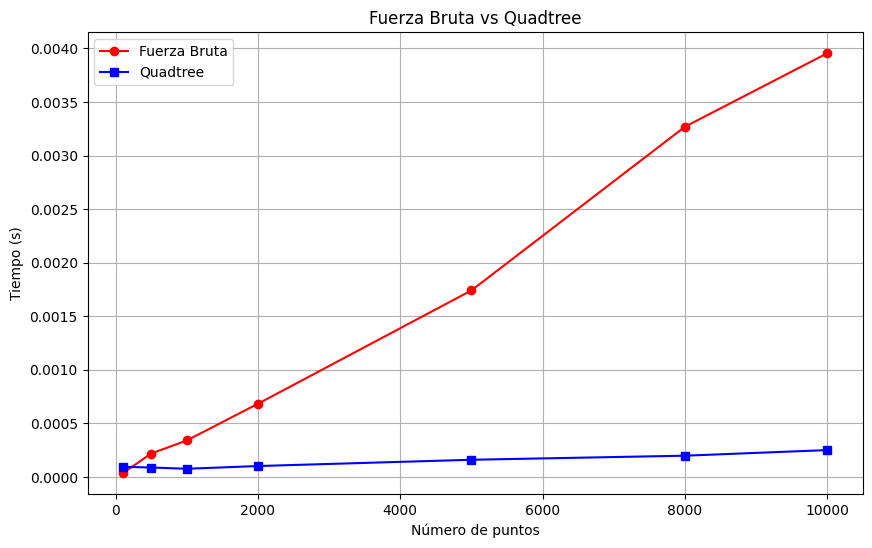

In [ ]:
import time
import random
import math
import matplotlib.pyplot as plt

def radio_fuerza_bruta(lista, q, r):
    res = []
    for p in lista:
        d = math.sqrt((p[0]-q[0])**2 + (p[1]-q[1])**2)
        if d <= r:
            res.append(p)
    return res

tamanos = [100, 500, 1000, 2000, 5000, 8000, 10000]
t_fb = []
t_qt = []

q = (5000, 5000)
r = 500
rep = 30

for n in tamanos:
    puntos = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(n)]
    arbol = quad(puntos)

    ini = time.time()
    for _ in range(rep):
        radio_fuerza_bruta(puntos, q, r)
    t_fb.append((time.time() - ini) / rep)

    ini = time.time()
    for _ in range(rep):
        radio(arbol, q, r)
    t_qt.append((time.time() - ini) / rep)

plt.figure(figsize=(10,6))

plt.plot(tamanos, t_fb, 'r-o', label='Fuerza Bruta')
plt.plot(tamanos, t_qt, 'b-s', label='Quadtree')

plt.title("Fuerza Bruta vs Quadtree")
plt.xlabel("Número de puntos")
plt.ylabel("Tiempo (s)")
plt.legend()
plt.grid(True)

plt.show()

para cantidades pequeñas, la fuerza bruta puede ser igual o incluso más rápida, ya que no tiene el costo de construir la estructura del árbol. Sin embargo, a medida que aumenta el número de puntos, la complejidad de la fuerza bruta crece linealmente, mientras que el Quadtree reduce significativamente el número de comparaciones necesarias

El Quadtree comienza a ser más rápido que la fuerza bruta desde tamaños pequeños, aproximadamente desde los 500 a 1000 punto